In [1]:
import matplotlib.pyplot as plt
import numpy as np
import petab
import pandas as pd
import seaborn as sns

from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import contextualize_measurements
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from util import load_petab_base_files

DATA = "dream_cytof"
MODEL = "EGFR_MAPK__logobs"

# updated load_petab_base_files takes in a Conf object as argument
conf = Conf(model=MODEL, data=DATA)
files = load_petab_base_files(conf)
# Get the list of all cell-lines
all_samples = get_samples(conf.data)
print(len(all_samples))

52


In [2]:
mat = contextualize_measurements(
    measurement_table=files["measurement_table"],
    observable_table=files["observable_table"],
    contextualization="cytof_dynamic",
    samples=all_samples,  # no cell-line subsetting - keep all
    impute=False
)
print(mat.index.nunique())

52


Added subchallenge II cell-lines (12, so the total number of rows went from 40 to 52, 53 if including the previously excluded outlier, cHCC1599)

In [3]:
subset_to_EGF = False
if subset_to_EGF:
    mat = mat[[col for col in mat.columns if col[1] == "EGF"]]

# Need to subset to ERK, MEK and ERBB2 observables (i.e. remove p90RSK) to obtain previous results!

In [4]:
mat = mat[[col for col in mat.columns if col[0] in ["pERK_Y204_obs", "pMEK_S222_obs", "pERBB2_Y1248_obs"]]]

In [5]:
mat.shape

(52, 93)

In [6]:
mat_nonans = mat.dropna(how="any", axis=1)

In [7]:
mat_nonans.shape

(52, 16)

In [8]:
mat_nonans - mat_nonans.mean(axis=0)  # mat.mean(axis=0) is the average (for a specific perturbation, observable, timepoint) across ALL cell-lines

observableId                pERK_Y204_obs                                \
simulationConditionId                 EGF                                 
time                                 0.0       5.5       7.0       9.0    
preequilibrationConditionId                                               
c184A1                          -0.290323 -0.170248 -0.141566  0.100591   
c184B5                          -0.596831 -0.075207 -0.321419 -0.552005   
cBT20                            0.904672  0.258024  0.765983  0.663374   
cBT474                           0.189160 -0.412249 -0.556644 -0.315711   
cBT483                           0.040835  0.165737  0.346523  0.166412   
cBT549                          -0.126041  0.072552  0.341393  0.145756   
cCAL148                         -0.931016 -0.199498 -0.370126 -0.099048   
cCAL51                          -0.275305  0.304880  0.126233  0.315829   
cCAL851                          0.389397  0.088595 -0.093782  0.241532   
cDU4475                          0.375928 -0.535859 -1.047766 -0.608447   
cEFM192A                        -0.277241 -0.783409 -0.481412 -0.389969   
cEVSAT                          -1.138983 -1.011366 -1.019786 -1.159841   
cHBL100                          0.045148  0.301627  0.530327  0.195898   
cHCC1187                         0.339122  0.376732  0.278158  0.470939   
cHCC1395                        -0.667384  0.133871 -0.012417  0.017335   
cHCC1419                         0.841534  0.299204 -0.303913 -0.076994   
cHCC1428                        -0.327630  0.618568  0.654389  0.665776   
cHCC1500                        -0.680130 -1.389128 -1.866474 -1.611181   
cHCC1569                        -0.201058  0.138677  0.143343  0.095708   
cHCC1806                        -0.543675 -0.192656  0.012756 -0.253848   
cHCC1937                         0.759349  0.999137  0.905406  0.943511   
cHCC1954                         0.405299  0.618899  0.319437  0.479608   
cHCC202                         -0.355421 -0.730265 -0.246883 -0.264649   
cHCC2185                         0.276090 -0.006583 -0.033804  0.136823   
cHCC3153                         0.762043  0.469078  0.397129  0.250637   
cHCC38                           1.541582  1.128165  1.174269  1.124730   
cHCC70                           0.355405  0.029069  0.551302  0.183211   
cHDQP1                           0.677382  0.403135  0.486011  0.538138   
cHs578T                         -0.104291  0.744083  0.715015  0.648199   
cJIMT1                           0.292118  0.157733 -0.219588  0.088198   
cMCF10A                         -0.825163 -0.256649  0.018522  0.041310   
cMCF12A                         -0.943330 -0.339457  0.060130 -0.499407   
cMCF7                           -1.160622 -1.206903 -0.942842 -1.104791   
cMDAMB134VI                     -0.002003 -0.634985 -0.746102 -0.689500   
cMDAMB157                       -0.168027  0.469075  0.479711  0.385375   
cMDAMB175VII                     0.224733  0.215724  0.198325  0.354197   
cMDAMB231                        0.153419  0.209745  0.357487  0.373123   
cMDAMB361                       -0.837924  0.064751  0.013135  0.018549   
cMDAMB415                        0.332734 -1.055851 -1.191715 -1.487649   
cMDAMB453                       -0.007881  0.006823  0.090510 -0.085001   
cMDAMB468                        0.631293  0.323203  0.069066  0.226581   
cMFM223                          0.464344 -0.234528 -0.563356 -0.612480   
cMPE600                          0.216266 -0.448998 -0.414698 -0.418413   
cMX1                            -0.196471  0.106732  0.022989  0.186618   
cOCUBM                          -0.262296  0.570210  0.297004  0.137780   
cSKBR3                           0.137526  0.217577  0.592274  0.507750   
cT47D                           -1.028664 -0.049398  0.008263  0.094382   
cUACC3199                        1.313457  1.063399  1.329564  1.163458   
cUACC812                        -0.126367 -0.688620 -0.627095 -0.526362   
cUACC893                 

In [9]:
res = (mat_nonans - mat_nonans.mean(axis=0)).apply(lambda x: np.power(x, 2)).mean(axis=1)
res

preequilibrationConditionId
c184A1          0.041350
c184B5          0.143818
cBT20           0.746146
cBT474          0.090961
cBT483          0.160505
cBT549          0.153916
cCAL148         0.140265
cCAL51          0.128943
cCAL851         0.040094
cDU4475         0.401291
cEFM192A        0.091115
cEVSAT          0.723352
cHBL100         0.050161
cHCC1187        0.144224
cHCC1395        0.094635
cHCC1419        0.076940
cHCC1428        0.218776
cHCC1500        0.946077
cHCC1569        0.042892
cHCC1806        0.379439
cHCC1937        0.612599
cHCC1954        0.271571
cHCC202         0.201000
cHCC2185        0.106909
cHCC3153        0.082088
cHCC38          0.575759
cHCC70          0.102315
cHDQP1          0.331753
cHs578T         0.380034
cJIMT1          0.190301
cMCF10A         0.112520
cMCF12A         0.389037
cMCF7           0.766167
cMDAMB134VI     0.253542
cMDAMB157       0.178039
cMDAMB175VII    0.353602
cMDAMB231       0.297543
cMDAMB361       0.292900
cMDAMB415       0.4588

In [10]:
res.sort_values(ascending=False).head(10)
# top 5 cell-lines for deviation from the mean: cMCF7, cBT20, cHCC1500, cEVSAT, cHCC2185 -> 5 CV splits
# following 5: cHCC38, cHCC1937, cDU4475, cMDAMB361, cMDAMB415

preequilibrationConditionId
cHCC1500     0.946077
cUACC3199    0.904298
cMCF7        0.766167
cBT20        0.746146
cEVSAT       0.723352
cHCC1937     0.612599
cHCC38       0.575759
cMDAMB415    0.458811
cDU4475      0.401291
cMCF12A      0.389037
dtype: float64

We get a new cell-line in second place, cUACC3199, but the one in first place is a pre-existing cell-line, which is now top-ranking, meaning the addition of subchallenge II cell-lines changed the data mean. Those cell-lines lack one of the perturbation conditions (either iEGFR or iMEK) -- maybe we should only compute these residuals based on EGF? Can use `subset_to_EGF` flag above, but results do not change (apart from qualitative arrangement in PCA space, but top deviating cell-lines are the same)

In [11]:
res.sort_values(ascending=False).index.tolist()

['cHCC1500',
 'cUACC3199',
 'cMCF7',
 'cBT20',
 'cEVSAT',
 'cHCC1937',
 'cHCC38',
 'cMDAMB415',
 'cDU4475',
 'cMCF12A',
 'cHs578T',
 'cHCC1806',
 'cMDAMB175VII',
 'cHDQP1',
 'cMDAMB231',
 'cMDAMB361',
 'cHCC1954',
 'cMDAMB134VI',
 'cMFM223',
 'cHCC1428',
 'cSKBR3',
 'cHCC202',
 'cUACC893',
 'cJIMT1',
 'cMDAMB157',
 'cBT483',
 'cBT549',
 'cHCC1187',
 'c184B5',
 'cCAL148',
 'cMDAMB453',
 'cCAL51',
 'cMX1',
 'cMCF10A',
 'cUACC812',
 'cHCC2185',
 'cOCUBM',
 'cHCC70',
 'cHCC1395',
 'cEFM192A',
 'cBT474',
 'cMDAMB468',
 'cHCC3153',
 'cT47D',
 'cHCC1419',
 'cZR751',
 'cZR7530',
 'cHBL100',
 'cMPE600',
 'cHCC1569',
 'c184A1',
 'cCAL851']

<Axes: ylabel='Frequency'>

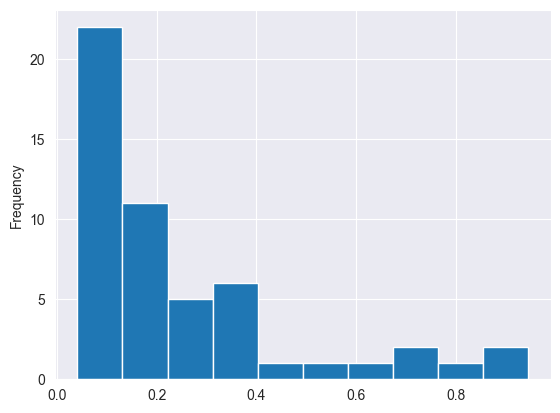

In [12]:
res.plot.hist()

No new outliers, defined based on this previous rule of any cell-line exhibiting a massive deviation from the data mean (2.0)

In [13]:
list(res[res.values > 2].index)  # only cell-line, 'cHCC1599', has already been dropped as outlier

[]

In [14]:
mat.drop(list(res[res.values > 2].index), axis=0, inplace=True)

In [15]:
X = mat.values
# impute missing values prior to PCA
X_imputed = KNNImputer().fit_transform(X)

pca = PCA(n_components=10)
Xt = pca.fit_transform(X_imputed)

In [16]:
Xt.shape  # it appears 3 other cell-lines have been dropped (no transcriptomic data), previous notebook had 43 remaining cell-lines

(52, 10)

In [17]:
X.shape

(52, 93)

In [18]:
Xt[:, 0]

array([-0.34573823, -0.82042123, -6.29200124, -0.11968599,  1.9081027 ,
       -0.59438322,  0.23277024, -1.37358543, -0.76395064, -1.56497759,
        2.09833229,  3.58188362,  0.98341841, -3.04608044,  0.75404214,
        1.03228927, -1.83709918,  4.57075855, -0.102603  ,  1.97122792,
       -4.08865608, -4.01701266,  3.34280547, -4.84969337, -0.8803934 ,
       -4.10987212,  0.85564419, -3.85416392, -0.0363133 , -2.84816328,
        0.28726348,  2.81012017,  6.40723648,  5.06766904, -0.13397462,
       -1.3853737 , -1.77612106,  2.9497218 ,  2.91902251,  2.16874635,
       -0.90901222,  0.0470143 ,  1.28412344,  1.3290546 ,  0.32691464,
       -1.22253676, -0.65840267, -4.78993394,  2.41675658,  2.81212023,
        0.94976537, -0.68665451])

/Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


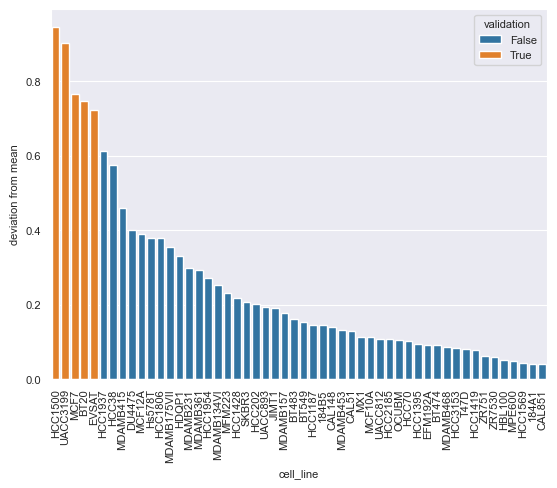

In [19]:
plt.rcParams.update({'font.size': 8})
res.name = "deviation from mean"
res.index.name = "cell_line"
res_df = res.reset_index()
res_df[res.index.name] = res_df[res.index.name].apply(lambda x: x[1:])
threshold = res.sort_values(ascending=False).head(5).min()
res_df["validation"] = res_df[res.name] >= threshold
res_df.sort_values(res.name, ascending=False, inplace=True)
sns.barplot(res_df, x=res.index.name, y=res.name, hue="validation", dodge=False)
# rotate x-axis labels
plt.xticks(rotation=90)
# decrease font size
res_df.set_index(res.index.name, inplace=True)

In [20]:
res_df.index

Index(['HCC1500', 'UACC3199', 'MCF7', 'BT20', 'EVSAT', 'HCC1937', 'HCC38',
       'MDAMB415', 'DU4475', 'MCF12A', 'Hs578T', 'HCC1806', 'MDAMB175VII',
       'HDQP1', 'MDAMB231', 'MDAMB361', 'HCC1954', 'MDAMB134VI', 'MFM223',
       'HCC1428', 'SKBR3', 'HCC202', 'UACC893', 'JIMT1', 'MDAMB157', 'BT483',
       'BT549', 'HCC1187', '184B5', 'CAL148', 'MDAMB453', 'CAL51', 'MX1',
       'MCF10A', 'UACC812', 'HCC2185', 'OCUBM', 'HCC70', 'HCC1395', 'EFM192A',
       'BT474', 'MDAMB468', 'HCC3153', 'T47D', 'HCC1419', 'ZR751', 'ZR7530',
       'HBL100', 'MPE600', 'HCC1569', '184A1', 'CAL851'],
      dtype='object', name='cell_line')

In [21]:
N_COMPS = 2
df = pd.DataFrame(
    index=[c[1:] for c in mat.index],
    data=Xt[:, :N_COMPS],
    columns=["PC1", "PC2"],
)
df.index.name = res.index.name
# select 5 strongest outliers as validation set
df["validation"] = res_df["validation"]
df

,PC1,PC2,validation
cell_line,,,
184A1,-0.345738,-0.010993,False
184B5,-0.820421,-2.062765,False
BT20,-6.292001,-1.855932,True
BT474,-0.119686,-0.959080,False
BT483,1.908103,1.156141,False
BT549,-0.594383,2.031541,False
CAL148,0.232770,1.291533,False
CAL51,-1.373585,1.038675,False
CAL851,-0.763951,0.391009,False


In [22]:
# Add hue column based on whether cell-lines are among the top-deviating from the data mean and/or the hardest ones to generalise to for linear regressors (see hardest_cell_lines_regressors.ipynb)
hardest_cell_lines_regressors = ['MDAMB134VI', 'MDAMB415', 'BT20', 'HCC2185', 'DU4475']
df["hardest"] = df.index.isin(hardest_cell_lines_regressors)
df["hue"] = df["validation"].astype("int") + 2*df["hardest"].astype("int")

# df["hue"].replace(
#     {0: "No", 1: "Deviating", 2: "Hardest-Regressors", 3: "Both"}, inplace=True
# )

In [23]:
# Manually define annotation offsets to be able to read cell-line names
offsets = {
    "MCF7": {"ox": -1.7, "oy": -0.2},
    "EVSAT": {"ox": -1.0, "oy": -1},
    "HCC1500": {"ox": 0.4, "oy": -0.2},
    "BT20": {"ox": 0.3, "oy": -0.2},
    "DU4475": {"ox": 0.3, "oy": -0.2},
    "HCC2185": {"ox": 0.3, "oy": 0},
    "MDAMB134VI": {"ox": 0.3, "oy": -0.2},
    "MDAMB415": {"ox": 0.1, "oy": 0.3},
    "UACC3199": {"ox": -1.5, "oy": 0.3},
    # "UACC893": {"ox": 0.3, "oy": -0.2},
}

In [24]:
df[df.validation]

,PC1,PC2,validation,hardest,hue
cell_line,,,,,
BT20,-6.292001,-1.855932,True,True,3
EVSAT,3.581884,-2.762321,True,False,1
HCC1500,4.570759,-2.032653,True,False,1
MCF7,6.407236,-0.917750,True,False,1
UACC3199,-4.789934,0.382539,True,False,1


# ICSB 2025 talk plot

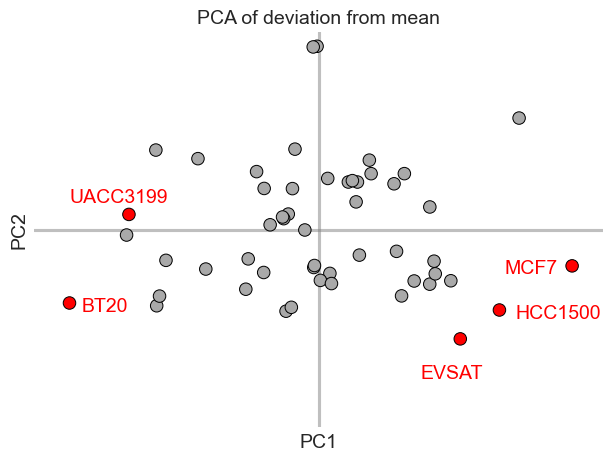

In [25]:
# Hue legend:
# 0: neither among top deviating from data mean nor among hardest cell-lines according to regressors;
# 1: among top deviating from data mean, not among hardest cell-lines according to regressors;
# 2: not among top deviating from data mean, but among the hardest cell-lines according to regressors;
# 3: both among top deviating cell-lines from data mean and among hardest cell-lines according to regressors

sns.set_context("talk", font_scale=0.7)
g = sns.scatterplot(
    data=df, 
    x="PC1", 
    y="PC2", 
    hue="validation",
    palette={True: "red", False: "darkgray"},
    edgecolor="black",
    legend=False
)
# add cell-line labels for 5 validation cell-lines
for _, r in df.iterrows():
    if r.validation:
        plt.annotate(r.name, (r.PC1+offsets[r.name]["ox"], r.PC2+offsets[r.name]["oy"]), color="red", fontsize=14)
    # if r.hardest:
    #     plt.annotate(r.name, (r.PC1+offsets[r.name]["ox"], r.PC2+offsets[r.name]["oy"]), color="blue")

# export with transparent background and high dpi, remove grid
# no box around plot
# add dashed line at 0 for both axes with low order to ensure it is behind the data points
# make plot square
# make axis limits equal and remove axis labels
g.set(xlim=(-7.2, 7.2), ylim=(-5, 5), aspect=1.0, xticks=[], yticks=[])
g.set_xlabel("PC1", fontsize=14)
g.set_ylabel("PC2", fontsize=14)
#
plt.axhline(0, color='gray', zorder=0, alpha=0.5)
plt.axvline(0, color='gray', zorder=0, alpha=0.5)
plt.box(False)
plt.grid(False)
VE = sum(pca.explained_variance_ratio_[:2])
# plt.title(f"PCA of deviance from mean ({VE*100:.0f}% Variance Explained)")
plt.title(f"PCA of deviation from mean", fontsize=14)
plt.tight_layout()
plt.savefig("cytof_pca.png", transparent=True, dpi=300)


In [26]:
res_df = res.reset_index()
res_df["cell_line"] = res_df["cell_line"].apply(lambda x: x[1:])

scatter_df = df.reset_index().merge(res_df, on="cell_line", how="left")


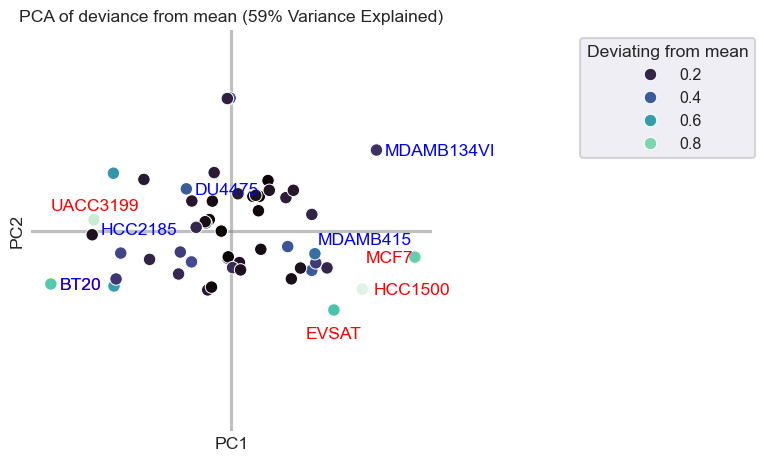

In [27]:
sns.set_context("talk", font_scale=0.7)
g = sns.scatterplot(
    data=scatter_df,
    x="PC1",
    y="PC2",
    hue="deviation from mean",
    palette="mako"
)
# add cell-line labels for 5 validation cell-lines
for _, r in df.iterrows():
    if r.validation:
        plt.annotate(r.name, (r.PC1+offsets[r.name]["ox"], r.PC2+offsets[r.name]["oy"]), color="red")
    if r.hardest:
        plt.annotate(r.name, (r.PC1+offsets[r.name]["ox"], r.PC2+offsets[r.name]["oy"]), color="blue")

# export with transparent background and high dpi, remove grid
# no box around plot
# add dashed line at 0 for both axes with low zorder to ensure it is behind the data points
# make plot square
# make axis limits equal and remove axis labels
g.set(xlim=(-7, 7), ylim=(-7, 7), aspect=1.0, xticks=[], yticks=[])
#
plt.axhline(0, color='gray', zorder=0, alpha=0.5)
plt.axvline(0, color='gray', zorder=0, alpha=0.5)
plt.box(False)
plt.grid(False)
VE = sum(pca.explained_variance_ratio_[:2])
plt.title(f"PCA of deviance from mean ({VE*100:.0f}% Variance Explained)")
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.35, 1), loc="upper left", title="Deviating from mean")
plt.savefig("cytof_pca_hue_meandev.png", transparent=True, dpi=300)

In [28]:
scatter_df[scatter_df.cell_line.isin(["UACC3199", "HCC2185"])]

,cell_line,PC1,PC2,validation,hardest,hue,deviation from mean
23,HCC2185,-4.849693,-0.138321,False,True,2,0.106909
47,UACC3199,-4.789934,0.382539,True,False,1,0.904298


In [29]:
scatter_df.sort_values("deviation from mean", ascending=False)

,cell_line,PC1,PC2,validation,hardest,hue,deviation from mean
17,HCC1500,4.570759,-2.032653,True,False,1,0.946077
47,UACC3199,-4.789934,0.382539,True,False,1,0.904298
32,MCF7,6.407236,-0.917750,True,False,1,0.766167
2,BT20,-6.292001,-1.855932,True,True,3,0.746146
11,EVSAT,3.581884,-2.762321,True,False,1,0.723352
20,HCC1937,-4.088656,-1.925630,False,False,0,0.612599
25,HCC38,-4.109872,2.008254,False,False,0,0.575759
38,MDAMB415,2.919023,-0.799154,False,True,2,0.458811
9,DU4475,-1.564978,1.463949,False,True,2,0.401291
31,MCF12A,2.810120,-1.379948,False,False,0,0.389037


In [30]:
pca.explained_variance_ratio_

array([0.42640214, 0.15988793, 0.12527461, 0.05882563, 0.04185317,
       0.03680313, 0.02231161, 0.01711531, 0.01471533, 0.01284217])

In [31]:
pca.components_.shape

(10, 93)

In [32]:
pc_mat = pd.DataFrame(
    index=[f"PC{i}" for i in np.arange(N_COMPS)],
    data=pca.components_[:N_COMPS, :],
    columns=mat.columns,
)
pc_mat

observableId          pERBB2_Y1248_obs                                \
simulationConditionId              EGF                                 
time                              0.0       5.5       7.0       9.0    
PC0                          -0.060807 -0.112427 -0.108431 -0.117002   
PC1                          -0.099838 -0.067461 -0.096734 -0.102892   

observableId                                                                 \
simulationConditionId                                                         
time                       13.0          14.0      17.0      23.0      30.0   
PC0                   -0.113117 -2.710505e-20 -0.123380 -0.094136 -0.118231   
PC1                   -0.117025  1.110223e-16 -0.086527 -0.114986 -0.107821   

observableId                     ... pMEK_S222_obs                          \
simulationConditionId            ...          iMEK                           
time                       40.0  ...          7.0       9.0           12.0   
PC0                   -0.125140  ...     -0.080229 -0.087116 -1.468051e-31   
PC1                   -0.131277  ...     -0.088820 -0.112336  1.371176e-31   

observableId                                                               \
simulationConditionId                                                       
time                       13.0          14.0          15.0          16.0   
PC0                   -0.099438 -1.468051e-31  1.468051e-31 -1.468051e-31   
PC1                   -0.097330  1.371176e-31 -1.371176e-31  1.371176e-31   

observableId                                         
simulationConditionId                                
time                       17.0      40.0      60.0  
PC0                   -0.078031 -0.095844 -0.096105  
PC1                   -0.093839 -0.103552 -0.110809  

[2 rows x 93 columns]

In [33]:
pc_mat.reset_index().columns

MultiIndex([(           'index',      '',   ''),
            ('pERBB2_Y1248_obs',   'EGF',  0.0),
            ('pERBB2_Y1248_obs',   'EGF',  5.5),
            ('pERBB2_Y1248_obs',   'EGF',  7.0),
            ('pERBB2_Y1248_obs',   'EGF',  9.0),
            ('pERBB2_Y1248_obs',   'EGF', 13.0),
            ('pERBB2_Y1248_obs',   'EGF', 14.0),
            ('pERBB2_Y1248_obs',   'EGF', 17.0),
            ('pERBB2_Y1248_obs',   'EGF', 23.0),
            ('pERBB2_Y1248_obs',   'EGF', 30.0),
            ('pERBB2_Y1248_obs',   'EGF', 40.0),
            ('pERBB2_Y1248_obs',   'EGF', 60.0),
            ('pERBB2_Y1248_obs', 'iEGFR',  0.0),
            ('pERBB2_Y1248_obs', 'iEGFR',  7.0),
            ('pERBB2_Y1248_obs', 'iEGFR',  9.0),
            ('pERBB2_Y1248_obs', 'iEGFR', 13.0),
            ('pERBB2_Y1248_obs', 'iEGFR', 14.0),
            ('pERBB2_Y1248_obs', 'iEGFR', 17.0),
            ('pERBB2_Y1248_obs', 'iEGFR', 40.0),
            ('pERBB2_Y1248_obs', 'iEGFR', 60.0),
            ('pERBB2

In [34]:
pc_mat_long = pd.melt(pc_mat.reset_index(), id_vars=[("index", "", "")])
pc_mat_long

,"(index, , )",observableId,simulationConditionId,time,value
0,PC0,pERBB2_Y1248_obs,EGF,0.0,-0.060807
1,PC1,pERBB2_Y1248_obs,EGF,0.0,-0.099838
2,PC0,pERBB2_Y1248_obs,EGF,5.5,-0.112427
3,PC1,pERBB2_Y1248_obs,EGF,5.5,-0.067461
4,PC0,pERBB2_Y1248_obs,EGF,7.0,-0.108431
...,...,...,...,...,...
181,PC1,pMEK_S222_obs,iMEK,17.0,-0.093839
182,PC0,pMEK_S222_obs,iMEK,40.0,-0.095844
183,PC1,pMEK_S222_obs,iMEK,40.0,-0.103552
184,PC0,pMEK_S222_obs,iMEK,60.0,-0.096105


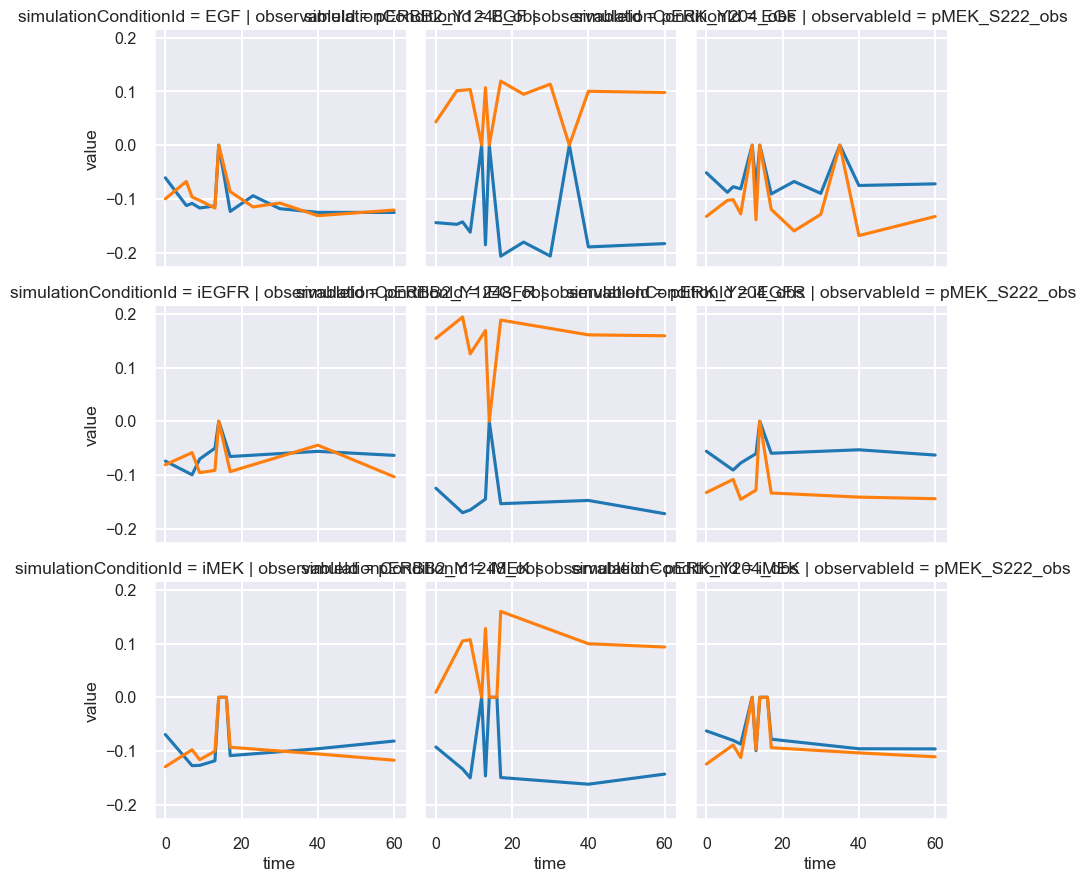

In [35]:
g = sns.FacetGrid(
    data=pc_mat_long, col=petab.OBSERVABLE_ID, row="simulationConditionId", hue=("index", "", "")
)
g.map_dataframe(sns.lineplot, x="time", y="value")
# Previous notebook showed 5 perturbation, but we have now removed iPI3K and iPKC -> 3 left (EGF, iEGFR, iMEK)